In [6]:
import pandas as pd
import numpy as np
from functools import reduce
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Load data
data_path = Path('..') / 'data' / 'cleaned' / 'amazon_products_sales_data_cleaned.csv'
df = pd.read_csv(data_path)
df['data_collected_at'] = pd.to_datetime(df['data_collected_at'])

print(f"Loaded {len(df)} products across {df['product_category'].nunique()} categories")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {', '.join(df.columns.tolist())}")

Loaded 42675 products across 15 categories
Dataset shape: (42675, 17)

Columns: product_title, product_rating, total_reviews, purchased_last_month, discounted_price, original_price, is_best_seller, is_sponsored, has_coupon, buy_box_availability, delivery_date, sustainability_tags, product_image_url, product_page_url, data_collected_at, product_category, discount_percentage


In [ ]:
# Statistical Summary

numeric_cols = ['discounted_price', 'discount_percentage', 
                'product_rating', 'total_reviews', 'purchased_last_month']

# Use map and lambda for statistical calculations
stats_summary = pd.DataFrame({
    col: {
        'count': df[col].count(),
        'mean': df[col].mean(),
        'median': df[col].median(),
        'std': df[col].std(),
        'min': df[col].min(),
        'max': df[col].max(),
        'missing': df[col].isna().sum(),
        'missing_pct': round(df[col].isna().sum() / len(df) * 100, 2)
    } for col in numeric_cols if col in df.columns
}).T.round(2)

print("Statistical Summary of Numeric Features:")
display(stats_summary)

Statistical Summary of Numeric Features:


,count,mean,median,std,min,max,missing,missing_pct
discounted_price,40613.0,243.23,84.99,473.35,2.16,5449.00,2062.0,4.83
discount_percentage,40613.0,6.55,0.00,12.74,0.00,85.42,2062.0,4.83
product_rating,41651.0,4.40,4.50,0.39,1.00,5.00,1024.0,2.40
total_reviews,41651.0,3087.11,343.00,13030.46,1.00,865598.00,1024.0,2.40
purchased_last_month,32164.0,1293.67,200.00,6318.32,50.00,100000.00,10511.0,24.63


In [ ]:
# Outlier Detection

def detect_outliers(series):
    """Detect outliers using IQR method"""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), round(len(outliers) / len(series) * 100, 2)

# Apply outlier detection using map
outlier_cols = ['discounted_price', 'product_rating', 'total_reviews', 'purchased_last_month']
outlier_analysis = pd.DataFrame({
    col: {'outlier_count': detect_outliers(df[col].dropna())[0],
        'outlier_percentage': detect_outliers(df[col].dropna())[1]}
    for col in outlier_cols if col in df.columns
}).T

print("Outlier Detection Summary (IQR Method):")
display(outlier_analysis)

Outlier Detection Summary (IQR Method):


,outlier_count,outlier_percentage
discounted_price,4888.0,12.04
product_rating,924.0,2.22
total_reviews,5862.0,14.07
purchased_last_month,4511.0,14.02


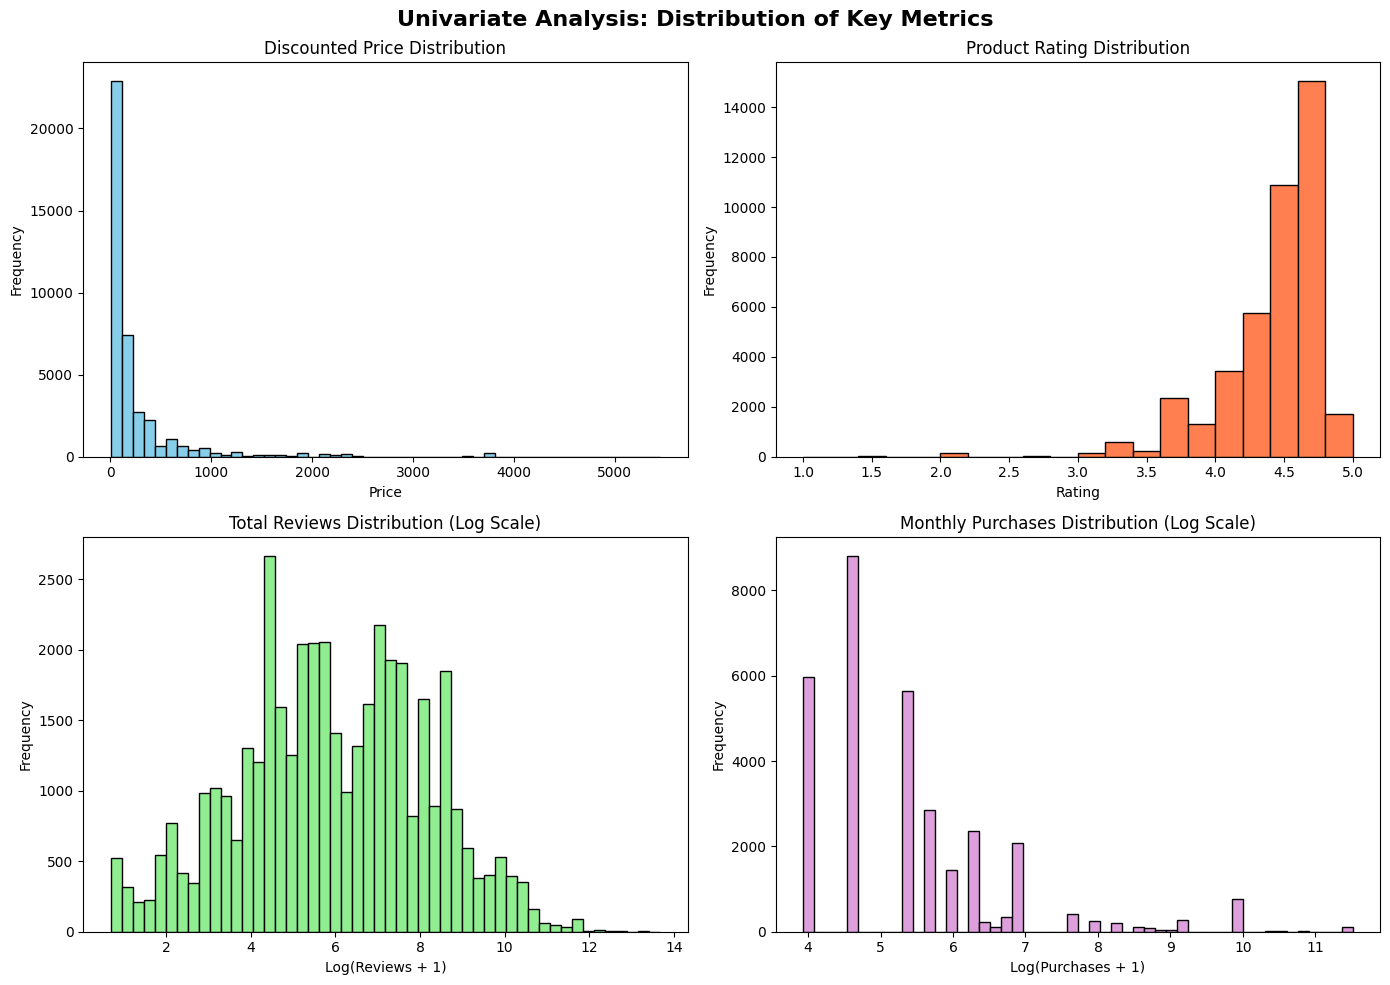

In [9]:
# Univariate Analysis: Distribution of Key Metrics
# Visualize distributions of important numerical features

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis: Distribution of Key Metrics', fontsize=16, fontweight='bold')

# Price distribution
axes[0, 0].hist(df['discounted_price'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Discounted Price Distribution')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')

# Rating distribution
axes[0, 1].hist(df['product_rating'].dropna(), bins=20, color='coral', edgecolor='black')
axes[0, 1].set_title('Product Rating Distribution')
axes[0, 1].set_xlabel('Rating')
axes[0, 1].set_ylabel('Frequency')

# Reviews distribution (log scale)
axes[1, 0].hist(np.log1p(df['total_reviews'].dropna()), bins=50, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Total Reviews Distribution (Log Scale)')
axes[1, 0].set_xlabel('Log(Reviews + 1)')
axes[1, 0].set_ylabel('Frequency')

# Purchases distribution (log scale)
axes[1, 1].hist(np.log1p(df['purchased_last_month'].dropna()), bins=50, color='plum', edgecolor='black')
axes[1, 1].set_title('Monthly Purchases Distribution (Log Scale)')
axes[1, 1].set_xlabel('Log(Purchases + 1)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Price Range vs Rating Analysis:


C:\Users\HP\AppData\Local\Temp\ipykernel_30052\136736104.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('price_range')


,price_range,product_rating_mean,product_rating_median,product_rating_std,total_reviews_median,product_title_count
0,<50,4.50,4.6,0.33,1131.0,15565
1,50-150,4.35,4.4,0.33,376.0,10779
2,150-500,4.37,4.4,0.36,151.0,8734
3,>500,4.33,4.4,0.59,72.0,4512


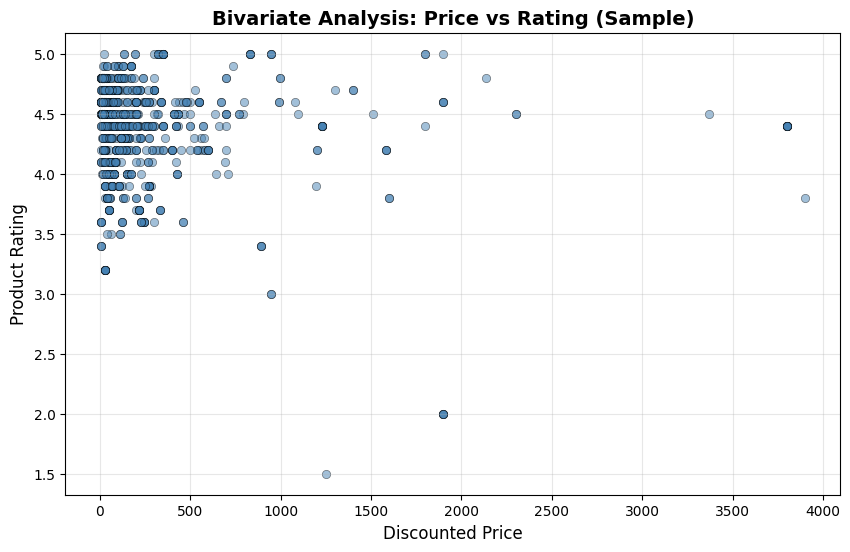

In [ ]:
# Bivariate Analysis: Price vs Rating Correlation

# Create price-rating analysis
bivariate_df = (
    df[df['discounted_price'].notna() & df['product_rating'].notna()]
    .assign(
        price_range=lambda x: pd.cut(x['discounted_price'], 
        bins=[0, 50, 150, 500, float('inf')],
        labels=['<50', '50-150', '150-500', '>500'])
    )
    .groupby('price_range')
    .agg({
        'product_rating': ['mean', 'median', 'std'],
        'total_reviews': 'median',
        'product_title': 'count'
    })
)

bivariate_df.columns = ['_'.join(col).strip('_') for col in bivariate_df.columns]
bivariate_df = bivariate_df.round(2).reset_index()

print("Price Range vs Rating Analysis:")
display(bivariate_df)

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
scatter_data = df[df['discounted_price'].notna() & df['product_rating'].notna()].sample(n=min(1000, len(df)))
ax.scatter(scatter_data['discounted_price'], scatter_data['product_rating'], 
    alpha=0.5, c='steelblue', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Discounted Price', fontsize=12)
ax.set_ylabel('Product Rating', fontsize=12)
ax.set_title('Bivariate Analysis: Price vs Rating (Sample)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.show()

Top 10 Categories by Product Count:


,product_category,product_count,discounted_price,product_rating,total_reviews,purchased_last_month
0,Other Electronics,8755,145.08,4.43,19154435.0,3425800.0
1,Laptops,8693,494.96,4.34,17753255.0,3416450.0
2,Phones,6563,159.04,4.30,29082511.0,3729550.0
3,Cameras,3677,443.66,4.50,5434741.0,835300.0
4,Power & Batteries,2877,53.51,4.61,20813316.0,26151450.0
5,TV & Display,2630,177.21,4.49,4525910.0,715750.0
6,Chargers & Cables,1833,125.69,4.41,7323766.0,822150.0
7,Storage,1630,136.36,4.36,6681598.0,493650.0
8,Speakers,1345,178.15,4.50,1387315.0,224750.0
9,Networking,1070,217.75,4.23,1757965.0,277050.0


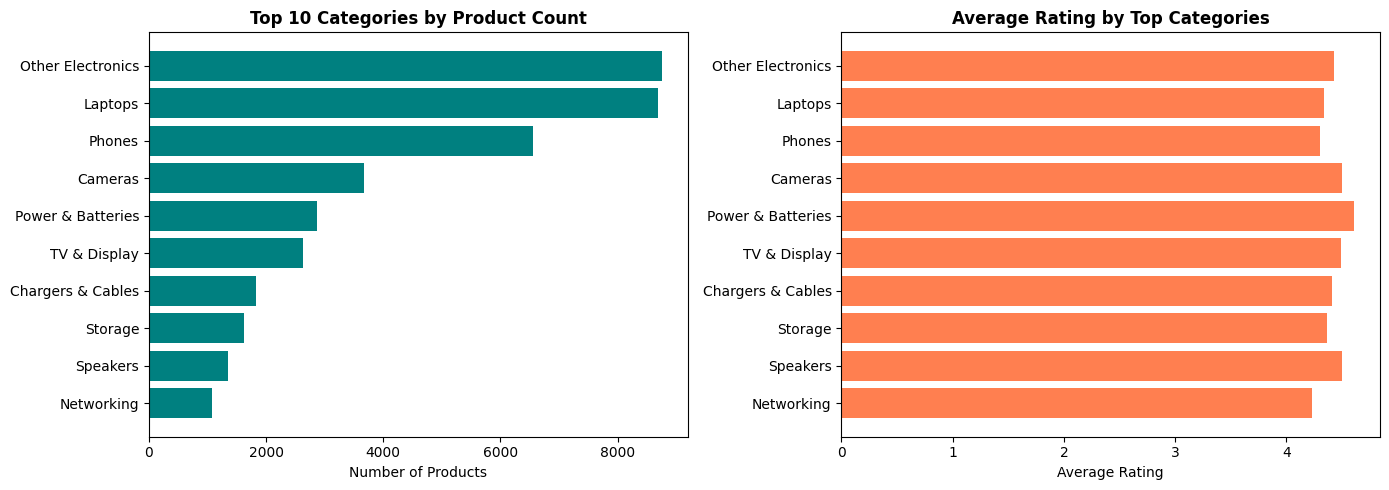

In [11]:
# Categorical Analysis using Lambda and Reduce
# Analyze distribution and aggregations across categories

# Top categories by product count
category_stats = (
    df.groupby('product_category')
    .agg({
        'product_title': 'count',
        'discounted_price': 'mean',
        'product_rating': 'mean',
        'total_reviews': 'sum',
        'purchased_last_month': 'sum'
    })
    .rename(columns={'product_title': 'product_count'})
    .round(2)
    .sort_values('product_count', ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 Categories by Product Count:")
display(category_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart for top categories
axes[0].barh(category_stats['product_category'], category_stats['product_count'], color='teal')
axes[0].set_xlabel('Number of Products')
axes[0].set_title('Top 10 Categories by Product Count', fontweight='bold')
axes[0].invert_yaxis()

# Average rating by category
axes[1].barh(category_stats['product_category'], category_stats['product_rating'], color='coral')
axes[1].set_xlabel('Average Rating')
axes[1].set_title('Average Rating by Top Categories', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()